In [1]:
from ase.io import read, write
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
atoms = read("./zn_charges.extxyz", index=":")

In [3]:
element_list = []
charges_list = []
for i in range(len(atoms)):
    element_list += atoms[i].get_chemical_symbols()
    charges_list += list(atoms[i].get_charges())

In [4]:
df = pd.DataFrame({"Atoms": element_list, "Predicted Charges": charges_list})
df

,Atoms,Predicted Charges
0,O,-3.495976
1,H,1.766089
2,H,1.860972
3,O,-3.529491
4,H,1.790591
...,...,...
975190,H,1.795299
975191,H,1.841573
975192,Zn,-2.384369
975193,Zn,-2.362564


(0.0, 100912.0)

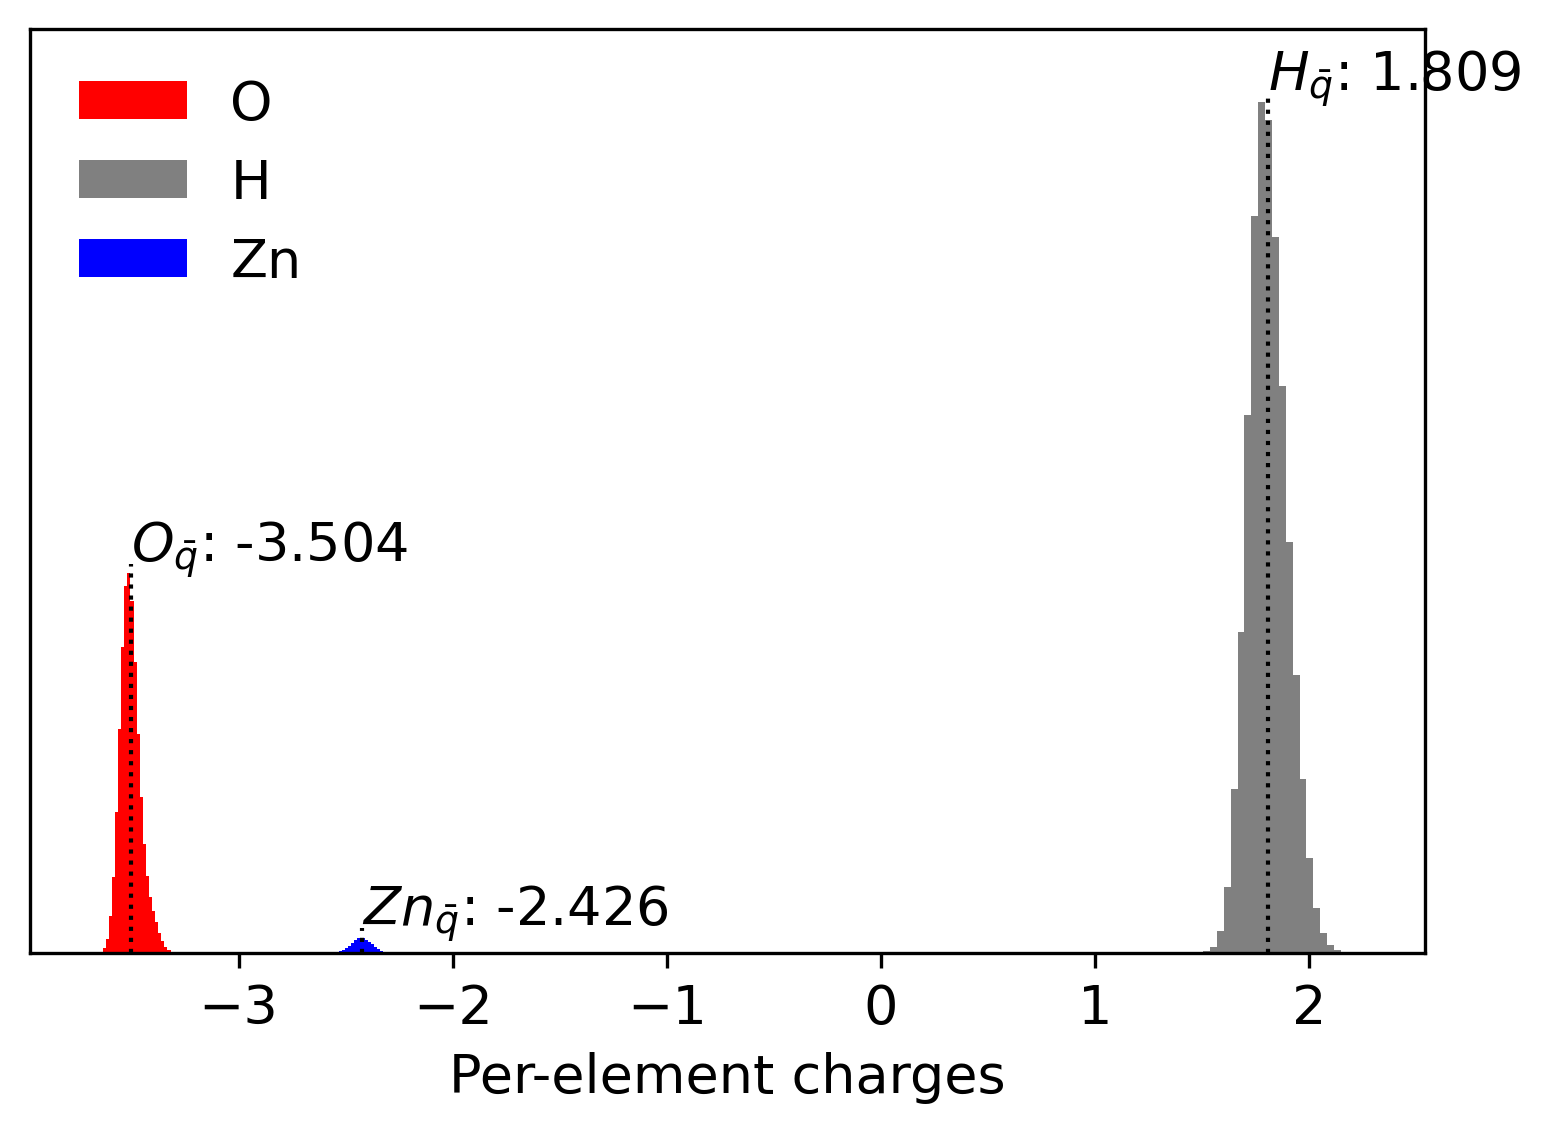

In [6]:
O = df[df["Atoms"] == "O"]["Predicted Charges"]
H = df[df["Atoms"] == "H"]["Predicted Charges"]
Zn = df[df["Atoms"] == "Zn"]["Predicted Charges"]

plt.figure(figsize=(6,4), dpi=300)

counts_O, bins, _ = plt.hist(O, bins=30, color='red', label="O")
counts_H, bins, _ = plt.hist(H, bins=30, color ='grey', label = "H")
counts_Zn, bins, _ = plt.hist(Zn, bins=30, color ='blue', label = "Zn")

plt.xlabel("Per-element charges", fontsize=13)
plt.xticks(fontsize=13)
plt.yticks([])
# plt.xlim([-4,3])

plt.legend(frameon=False, fontsize=13)

O_mean = round(float(O.mean()), 3)
H_mean = round(float(H.mean()), 3)
Zn_mean = round(float(Zn.mean()), 3)

plt.vlines(O_mean, 0, max(counts_O) + 1000, linestyles=':', linewidth=1, color='black')
plt.vlines(H_mean, 0, max(counts_H) + 1000, linestyles=':', linewidth=1, color='black')
plt.vlines(Zn_mean, 0, max(counts_Zn) + 1000, linestyles=':', linewidth=1, color='black')

plt.annotate(rf"$O_{{\bar{{q}}}}$: {O_mean}", (O_mean, max(counts_O) + 1300), fontsize=13)
plt.annotate(rf"$H_{{\bar{{q}}}}$: {H_mean}", (H_mean, max(counts_H) + 1300), fontsize=13)
plt.annotate(rf"$Zn_{{\bar{{q}}}}$: {Zn_mean}", (Zn_mean, max(counts_Zn) + 1300), fontsize=13)

plt.ylim([0, max(counts_H)+8000])